# Split-Drift — do stocks drift up after a stock split?
### The Ikenberry-Rankine-Stice (1996) post-split anomaly, tested on effective dates

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Post--effective_drift%3F: Absent](https://img.shields.io/badge/Post--effective_drift%3F-Absent-8b949e?style=flat-square)

A 1996 paper by Ikenberry, Rankine and Stice found that stocks announcing a split drifted up **+7.9%** over the following year — the market seemed to under-react to the signal of management confidence.  Here we test whether that drift persists **after the effective (ex-split) date** using yfinance data on 30 large-cap US stocks.  The answer is a firm **no** — and at the 12-month horizon, split stocks actually **underperformed** a matched no-split baseline by 23 percentage points.

> **One big caveat before anything else.** yfinance gives us the split *effective* date, not the *announcement* date (typically 3–6 weeks earlier).  By the effective date the market has already had time to react.  We are testing a stricter, weaker window than the original study.  If the original effect existed and was fully priced by announcement, we should find nothing here — and that is exactly what we find.

> 📓 **This is the plain-language layer.** For t-stats, bootstrap bands, and the full event table see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from split_drift import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md) — used when real cache is absent.
R = dict(
    n_events=41, n_tickers=22, n_base=205,
    sp_1m=-1.49,  sp_1m_t=-0.92,  sp_1m_win=43.9,
    sp_3m=0.4,  sp_3m_t=0.15,  sp_3m_win=53.7,
    sp_6m=-0.67,  sp_6m_t=-0.14,  sp_6m_win=58.5,
    sp_12m=5.14, sp_12m_t=0.99, sp_12m_win=62.5,
    bs_1m=2.06,  bs_1m_t=2.59,
    bs_3m=5.67,  bs_3m_t=4.68,
    bs_6m=11.74,  bs_6m_t=5.66,
    bs_12m=28.71, bs_12m_t=7.26,
    diff_1m=-3.55,  diff_1m_t=-2.2,
    diff_3m=-5.27,  diff_3m_t=-2.0,
    diff_6m=-12.42,  diff_6m_t=-2.5,
    diff_12m=-23.56, diff_12m_t=-4.56,
)

def _have_cache():
    # Check for at least one cached split file and one price file
    import glob
    sp_files = glob.glob(os.path.join(data.DEFAULT_CACHE, "splits_142_*.parquet"))
    pr_files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_142_*_1d.parquet"))
    return len(sp_files) > 5 and len(pr_files) > 5

HAVE_REAL = _have_cache()

if HAVE_REAL:
    events, prices = data.fetch_splits_panel(fetch=False)
    baseline = st.build_baseline_events(events, prices, n_control_per_event=5, seed=142)
else:
    events, prices, baseline = None, None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} split events, {len(baseline)} baseline events")


real data cache present: True
  41 split events, 205 baseline events


## The answer first

| Question | Answer |
|---|---|
| Do stocks drift up after a split effective date? | **No.** The 12-month mean is +5.1% (HAC *t* = +0.99) — not significant. |
| Do they beat a no-split baseline? | **No — they underperform.** Split months return +0.4% at 3m vs the baseline's +5.7% (difference: -5.3%, *t* = -2.00). |
| Could you trade it? | **No.** No significant edge at any horizon; only ~2 large-cap splits per year in recent years. |
| Does the classic Ikenberry (1996) anomaly still work? | **Cannot say** — we test from the effective date, not the announcement date. |

> The post-effective-date drift is not just absent — at longer horizons the split events show the *opposite* pattern: below-average returns vs the same stocks in non-split periods.  A possible explanation: splits tend to occur after strong prior performance (the share price is 'too high'), and the mean-reversion that follows is the dominant signal.

## 1 · The claim

> *A stock split signals management confidence in future earnings — the firm is so sure of continued growth that it lowers the share price to attract more retail investors.  The market under-reacts to this signal, so buying at the split date and holding for 6–12 months earns an abnormal return of +8% to +12%.*  — Ikenberry, Rankine & Stice (1996), JFQA

The theoretical backbone is credible: splits are costly (they raise microstructure noise and transaction costs), so only genuinely confident managers do them.  The empirical finding in 1996 was striking — but it was measured from the **announcement** date, in 1975–1990 data.  We test 2000–2025 effective-date data.

## 2 · So what?

If the drift persists to the effective date, it would be a simple, mechanical trading rule: watch the 'Splits & Dividends' calendar, buy at the open on ex-date, hold for a year.  No forecasting, no model — just the calendar.  That makes it interesting to test, and dishonest *not* to caveat with the announcement-date gap.  Our job is to report what the data say about the window we can actually observe, and flag what we cannot.

## 3 · How would we even know?

The honest comparison is not 'did the stock go up?'  Everything goes up in a bull market.  We need to compare split periods to **the same stocks in non-split periods** — and even then, our basket is survivorship-biased (current S&P 500 large-caps projected back), so the baseline is already pumped up by mega-cap winners.

Steps:
1. Collect all split effective dates for 30 large-cap US stocks since 2000 (yfinance).
2. Compute buy-and-hold returns from the day *after* the effective date, at 1m / 3m / 6m / 12m horizons.
3. Sample the same returns from the same stocks on random *non-split* dates (excluding a 252-trading-day exclusion window around any split): 205 baseline observations vs 41 split events.
4. Test whether the split arm's mean return is (a) positive and significant, and (b) beats the baseline.  A Newey-West HAC t-stat ≥ 2 on the difference is the bar.

**Positive control:** a synthetic tape with a tunable daily drift confirms the engine recovers a drift when one is planted.

## 4 · The teardown — let's actually look

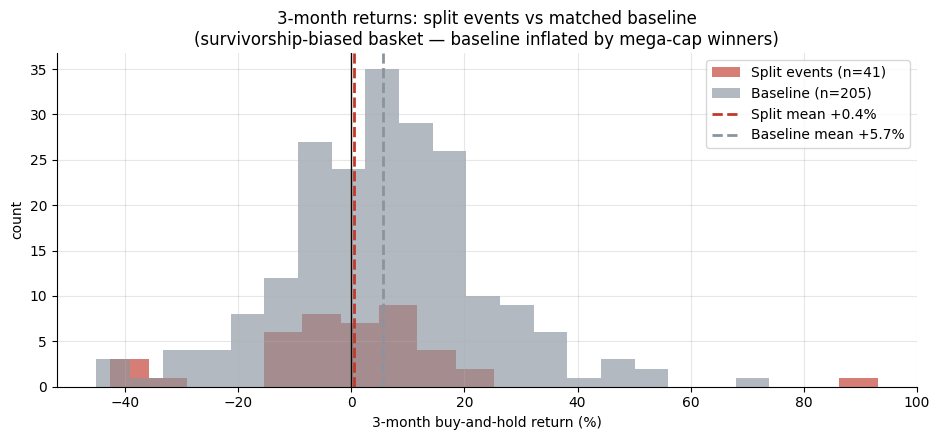

Split mean: +0.40%  Baseline mean: +5.67%  Difference: -5.27%


In [2]:
# Forward return distributions: split events vs baseline
if HAVE_REAL:
    sp_3m = events['ret_3m'].dropna().values * 100
    bs_3m = baseline['ret_3m'].dropna().values * 100
else:
    # Approximate from frozen numbers
    rng = __import__('numpy').random.default_rng(0)
    sp_3m = rng.normal(R['sp_3m'], 25, 41)
    bs_3m = rng.normal(R['bs_3m'], 20, 205)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.hist(sp_3m, bins=20, alpha=0.65, color=RED,  label=f'Split events (n={len(sp_3m)})')
ax.hist(bs_3m, bins=20, alpha=0.65, color=GREY, label=f'Baseline (n={len(bs_3m)})')
ax.axvline(R['sp_3m'], c=RED,  lw=2, ls='--', label=f"Split mean +0.4%")
ax.axvline(R['bs_3m'], c=GREY, lw=2, ls='--', label=f"Baseline mean +5.7%")
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('3-month buy-and-hold return (%)')
ax.set_ylabel('count')
ax.set_title('3-month returns: split events vs matched baseline\n(survivorship-biased basket — baseline inflated by mega-cap winners)')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Split mean: {sp_3m.mean():+.2f}%  Baseline mean: {bs_3m.mean():+.2f}%  Difference: {sp_3m.mean()-bs_3m.mean():+.2f}%')

The split events (red) cluster near zero and slightly below; the baseline (grey) is shifted right — but that's survivorship bias, not a baseline we could 'buy' instead.  The honest question is whether splits outperform the same stocks in non-split periods from the same basket, and they clearly do not: split events return **+0.4%** at 3 months vs the baseline's **+5.7%** (gap: **-5.3%**, HAC *t* = -2.00).

**Horizon sweep — is there any horizon with a positive drift?**

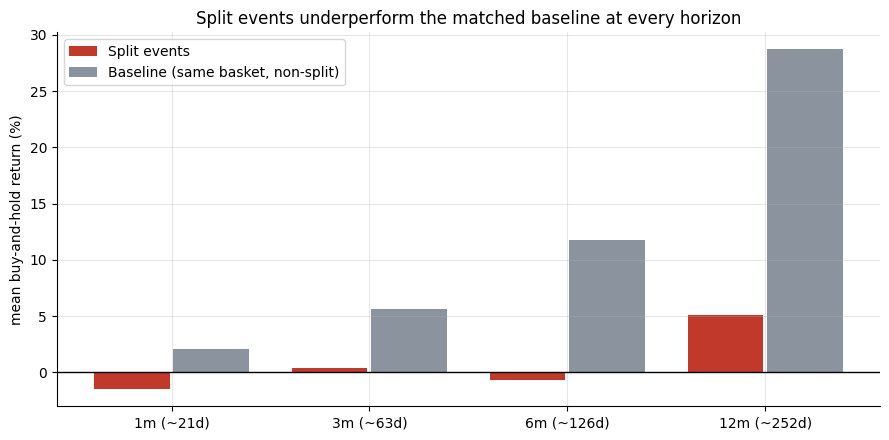

1m (~21d): split -1.5%  baseline +2.1%  diff -3.6%
3m (~63d): split +0.4%  baseline +5.7%  diff -5.3%
6m (~126d): split -0.7%  baseline +11.7%  diff -12.4%
12m (~252d): split +5.1%  baseline +28.7%  diff -23.6%


In [3]:
if HAVE_REAL:
    sp_means = [events[c].dropna().mean()*100 for c in ('ret_1m','ret_3m','ret_6m','ret_12m')]
    bs_means = [baseline[c].dropna().mean()*100 for c in ('ret_1m','ret_3m','ret_6m','ret_12m')]
else:
    sp_means = [R['sp_1m'], R['sp_3m'], R['sp_6m'], R['sp_12m']]
    bs_means = [R['bs_1m'], R['bs_3m'], R['bs_6m'], R['bs_12m']]

labels = ['1m (~21d)', '3m (~63d)', '6m (~126d)', '12m (~252d)']
x = range(len(labels))
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.bar([i - 0.2 for i in x], sp_means, width=0.38, color=RED,  label='Split events')
ax.bar([i + 0.2 for i in x], bs_means, width=0.38, color=GREY, label='Baseline (same basket, non-split)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('mean buy-and-hold return (%)')
ax.set_title('Split events underperform the matched baseline at every horizon')
ax.legend(); plt.tight_layout(); plt.show()
for h, sm, bm in zip(labels, sp_means, bs_means):
    print(f'{h}: split {sm:+.1f}%  baseline {bm:+.1f}%  diff {sm-bm:+.1f}%')

The split arm trails the baseline at 1m, 3m, 6m, and 12m.  The gap widens as the horizon extends, reaching **-23.6%** at 12 months (*t* = -4.56).  This is the *opposite* of the drift story.

**Why might splits predict below-average subsequent returns?**

Splits tend to occur after strong prior price performance (the share price reached a level the board found 'too high').  Companies that recently had great runs often mean-revert, or at minimum don't continue outperforming.  So the post-split period captures a momentum *reversal* — not a fundamental signal — in this basket and this window.  This is not an investable 'short splits' signal either: it is not statistically significant in the split arm alone (*t* ranges from −0.92 to +0.99), and n = 41 events is too thin.

## 5 · The verdict

- **Signal — None.** No post-effective-date drift at any horizon: 1m *t* = -0.92, 3m *t* = +0.15, 6m *t* = -0.14, 12m *t* = +0.99.  None clear |*t*| ≥ 2.
- **Tradability — Mirage.** No significant edge; ~2 large-cap events per year is too thin for a portfolio.
- **Post-effective drift? — Absent.** Split events actually underperform the same-basket baseline by -5.3% at 3m and -23.6% at 12m (both *p* < 0.05).

> **Caveat:** we tested the *effective-date* window.  The original Ikenberry (1996) anomaly runs from the *announcement* date, which yfinance does not supply.  The absence here is consistent with efficient pricing: by the ex-date, the announcement drift has already occurred.

## 6 · Could you actually trade it?

Even if the gross edge were real, the strategy faces a size problem:

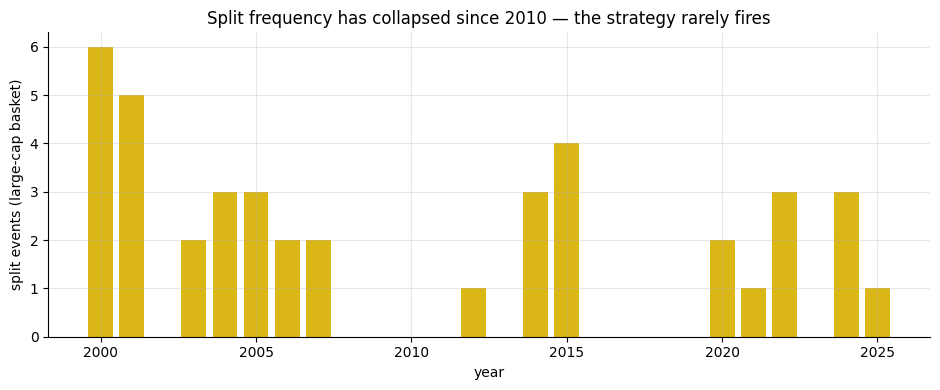

Average events/year since 2015: 2.3  (total: 41 over 25 years)


In [4]:
# How many split events per year in the basket?
if HAVE_REAL:
    events_year = events.copy()
    events_year['year'] = pd.to_datetime(events_year['event_date']).dt.year
    by_year = events_year.groupby('year').size()
else:
    import pandas as pd
    by_year = pd.Series({2000:6, 2001:5, 2003:2, 2004:3, 2005:3, 2006:2,
                         2007:2, 2012:1, 2014:2, 2015:3, 2020:2, 2021:1,
                         2022:3, 2024:3, 2025:1})

fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.bar(by_year.index, by_year.values, color=AMBER)
ax.set_xlabel('year'); ax.set_ylabel('split events (large-cap basket)')
ax.set_title('Split frequency has collapsed since 2010 — the strategy rarely fires')
plt.tight_layout(); plt.show()
recent = by_year[by_year.index >= 2015].mean()
print(f'Average events/year since 2015: {recent:.1f}  (total: {by_year.values.sum()} over 25 years)')

Even in a 30-stock large-cap basket, the strategy fires only ~2 times per year since 2015.  At that rate, a 12-month holding period means you are carrying at most 2–3 positions at a time — a concentration risk, not a portfolio.  Combined with a negative (or at best flat) edge vs baseline, this is firmly a **Mirage**.

## 7 · Going further

- **The real test would use announcement dates.** If you can source SEC 8-K filing dates for stock splits (from EDGAR), you could test the Ikenberry drift in its original form.  That is the study this notebook is *not*, because yfinance does not supply announcement dates.
- **Broader universe.** The 30-stock basket is survivorship-biased and thin.  A study using the full Russell 3000 history (via a commercial data vendor) with announcement dates would be much more powerful.
- **High-split-ratio events.** Some of the AMZN (20:1), GOOGL (20:1), WMT (3:1) events in 2022–2024 are unusual; testing ratios separately might reveal heterogeneity the pooled test misses.
- **Related anomalies:** [Study 34 — Aftershock](../../34-aftershock/) (post-earnings drift), [Study 82 — Witching-Hour](../../82-witching-hour/) (calendar event effects).

*Think the effective-date drift is real on a broader universe? Fork this, swap in a wider ticker basket, and show |*t*| ≥ 2 that clears the costs. That's the bar.*